# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [13]:
data = pd.read_csv('processed_clustering_result.csv')
data.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Total_Price_Binned,Cluster
0,ORD1,CUS1496,0,Vio Wasser,3,-0.278476,1.103266,1.552676,-0.101229,0,8/23/2023,High,2
1,ORD1,CUS1496,0,Evian,3,-0.285340,2.475869,1.552676,-0.006465,0,8/23/2023,High,2
2,ORD1,CUS1496,0,Sprite,2,-0.312108,1.845214,0.442538,-0.097292,0,8/23/2023,High,2
3,ORD1,CUS1496,0,Rauch Multivitamin,1,-0.171403,1.325850,1.552676,0.083156,0,8/23/2023,High,2
4,ORD1,CUS1496,0,Gerolsteiner,3,-0.332699,0.435513,1.552676,-0.205232,0,8/23/2023,Medium,0


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [14]:
# Pastikan dataset memiliki fitur dan target
# Misalnya, jika kolom target, sesuaikan dengan dataset Anda
target_column = 'Cluster'
features = data.drop(columns=['Cluster', 'Product', 'Order_Date', 'Total_Price_Binned','Customer_ID','Order_ID'])
target = data[target_column]

# Cek jumlah nilai NaN dalam target
print(target.isna().sum())


0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [16]:
# Membangun Model Klasifikasi
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [17]:
# Membuat prediksi
y_pred = model.predict(X_test)

Pada proses model klasifikasi ini menggunakan Metode Klasifikasi Random Forest Classifier, dengan random state sebesar 42 yang mana. Random Forest adalah metode ensemble learning yang menggabungkan banyak pohon keputusan (decision trees) untuk meningkatkan akurasi dan mengurangi overfitting

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [18]:
# Evaluasi Model Klasifikasi
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("F1-Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9998270494638534
F1-Score: 0.9998270428875932
Precision: 0.9998272048551706
Recall: 0.9998270494638534

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1112
           1       1.00      1.00      1.00      3718
           2       1.00      1.00      1.00       952

    accuracy                           1.00      5782
   macro avg       1.00      1.00      1.00      5782
weighted avg       1.00      1.00      1.00      5782



Berdasarkan hasil evaluasi model klasifikasi yang terlihat:

- Akurasi: 0.9998 (~99.98%)
- Precision: 0.9998 (~99.98%)
- Recall: 0.9998 (~99.98%)
- F1-Score: 0.9998 (~99.98%)

Dari classification report, terlihat bahwa setiap kelas (0, 1, 2) memiliki nilai precision, recall, dan f1-score sebesar 1.00, menunjukkan bahwa model bekerja hampir sempurna dalam membedakan kelas-kelas tersebut.

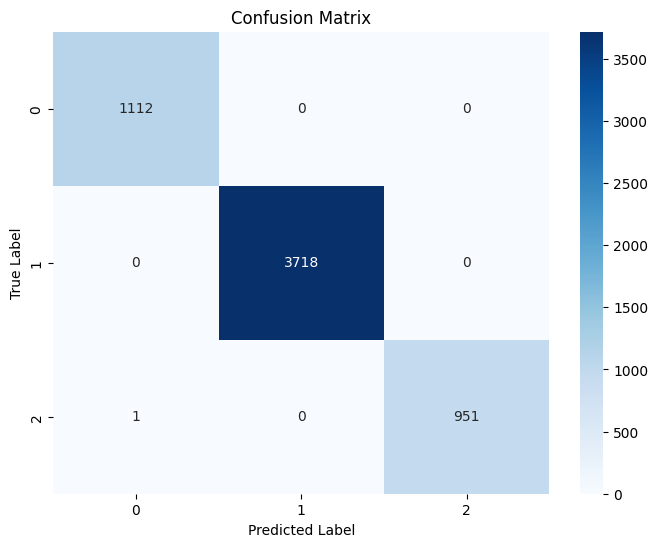

In [19]:
# Menghitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Diagonal Utama (Prediksi Benar):

- Kelas 0: 1112 prediksi benar (True Positive untuk kelas 0).
- Kelas 1: 3718 prediksi benar (True Positive untuk kelas 1).
- Kelas 2: 951 prediksi benar (True Positive untuk kelas 2).

Luar Diagonal (Prediksi Salah):

Baris 2, Kolom 0: 1 prediksi salah di mana kelas sebenarnya 2 tapi diprediksi sebagai 0 (False Negative untuk kelas 2, False Positive untuk kelas 0).
Nilai 0 lainnya menunjukkan tidak ada kesalahan prediksi antar kelas tersebut.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [20]:
# Tuning Model Klasifikasi (Opsional)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [21]:
# Evaluasi Model Setelah Tuning (Opsional)
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted')
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted')

print("Accuracy after tuning:", accuracy_tuned)
print("F1-Score after tuning:", f1_tuned)
print("Precision after tuning:", precision_tuned)
print("Recall after tuning:", recall_tuned)
print("\nClassification Report after tuning:\n", classification_report(y_test, y_pred_tuned))

Accuracy after tuning: 0.9996540989277066
F1-Score after tuning: 0.9996540989277066
Precision after tuning: 0.9996540989277066
Recall after tuning: 0.9996540989277066

Classification Report after tuning:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1112
           1       1.00      1.00      1.00      3718
           2       1.00      1.00      1.00       952

    accuracy                           1.00      5782
   macro avg       1.00      1.00      1.00      5782
weighted avg       1.00      1.00      1.00      5782



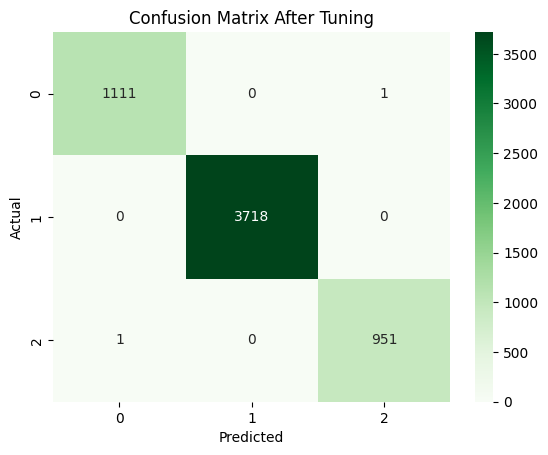

In [22]:
# Confusion Matrix after tuning
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix After Tuning')
plt.show()

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

1. **Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).**

- Metrik        Sebelum Tuning	Sesudah Tuning	    Perubahan
- Accuracy	    0.9998	        0.9996	            ↓ Sedikit menurun
- F1-Score	    0.9998	        0.9996	            ↓ Sedikit menurun
- Precision	    0.9998	        0.9996	            ↓ Sedikit menurun
- Recall	    0.9998	        0.9996	            ↓ Sedikit menurun

    Catatan:
    - Performa tetap sangat tinggi (mendekati 1.0), tetapi tuning justru sedikit menurunkan akurasi.
    - Kemungkinan tuning tidak signifikan atau overfitting pada data latih.

2. **Identifikasi kelemahan model, seperti:**

    - Confusion Matrix Sebelum Tuning
        - Hanya 1 kesalahan (Kelas 2 diprediksi sebagai Kelas 0).
        - Kelas 1 dominan (3718 sampel), tetapi model tetap baik untuk kelas minoritas.
    - Confusion Matrix Sesudah Tuning
        - Kesalahan bertambah:
            1 sampel Kelas 0 diprediksi sebagai Kelas 2.
            1 sampel Kelas 2 diprediksi sebagai Kelas 0.
        - Tuning tidak memperbaiki model, malah menambah noise.

    -  Potensi Masalah
        - Class Imbalance: Kelas 1 (3718) jauh lebih banyak daripada Kelas 0 (1112) dan 2 (952).
        - Overfitting: Model terlalu sempurna di data latih, tetapi tuning tidak meningkatkan generalisasi.
        - Data Leakage? Akurasi hampir 100% bisa mencurigakan (periksa preprocessing).

3. **Rekomendasi Tindakan Lanjutan**
    - Jika Performa Sudah Cukup (Accuracy ~99.98%)
        - Terapkan model langsung karena kesalahan sangat minim.
        - Pantau di produksi untuk memastikan tidak ada bias pada data baru.
    - Jika Ingin Lebih Optimal
        - Atasi Class Imbalance:
            - Gunakan teknik oversampling (SMOTE) atau bobot kelas.
        - Coba Algoritma Lain:
            - XGBoost/Gradient Boosting: Lebih robust terhadap imbalance.
            - SVM dengan kernel yang sesuai.
        - Validasi Lebih Ketat:
            - Gunakan cross-validation atau data validasi terpisah.
            - Periksa learning curve untuk deteksi overfitting.
        - Perbaiki Tuning:
            - Gunakan GridSearchCV/RandomizedSearchCV untuk hyperparameter.
            - Fokus pada recall/precision kelas minoritas (0 dan 2).
        - Investigasi Data
            - Cek distribusi fitur: Apakah ada outlier atau noise?
            - Pastikan tidak ada data leakage: Misalnya, data uji ikut dilatih.